# Notebook 1 — Data Loading & Preprocessing
**Project:** Chest X-ray Pneumonia Detection — Generalization Study

This notebook:
1. Connects to Kaggle and downloads both datasets
2. Loads images, resizes them, and normalizes pixel values
3. Creates stratified train/test splits
4. Saves preprocessed arrays to disk for use in later notebooks


## Step 1 — Installing & importing libraries

In [1]:
# Installing packages
!pip install kaggle opencv-python-headless scikit-learn numpy matplotlib tqdm --quiet

In [9]:
import os, numpy as np, cv2, matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

IMG_SIZE = 64
SEED = 42
np.random.seed(SEED)

def load_images_from_folder(folder, label, img_size=IMG_SIZE, max_images=None):
    images, labels = [], []
    folder = Path(folder)
    files = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    if max_images:
        rng = np.random.default_rng(SEED)
        files = rng.choice(files, size=min(max_images, len(files)), replace=False).tolist()
    for filepath in tqdm(files, desc=f'Loading {folder.name}'):
        img = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load Kaggle data
KAGGLE_ROOT = Path('data/kaggle/chest_xray')
X_train = np.concatenate([load_images_from_folder(KAGGLE_ROOT/'train'/'NORMAL', 0)[0],
                           load_images_from_folder(KAGGLE_ROOT/'train'/'PNEUMONIA', 1)[0]])
y_train = np.concatenate([load_images_from_folder(KAGGLE_ROOT/'train'/'NORMAL', 0)[1],
                           load_images_from_folder(KAGGLE_ROOT/'train'/'PNEUMONIA', 1)[1]])
X_test  = np.concatenate([load_images_from_folder(KAGGLE_ROOT/'test'/'NORMAL', 0)[0],
                           load_images_from_folder(KAGGLE_ROOT/'test'/'PNEUMONIA', 1)[0]])
y_test  = np.concatenate([load_images_from_folder(KAGGLE_ROOT/'test'/'NORMAL', 0)[1],
                           load_images_from_folder(KAGGLE_ROOT/'test'/'PNEUMONIA', 1)[1]])

# Dummy NIH arrays until the dataset is fixed
X_nih = X_test.copy()
y_nih = y_test.copy()

os.makedirs('preprocessed', exist_ok=True)
np.save('preprocessed/X_train.npy', X_train)
np.save('preprocessed/y_train.npy', y_train)
np.save('preprocessed/X_test.npy',  X_test)
np.save('preprocessed/y_test.npy',  y_test)
np.save('preprocessed/X_nih.npy',   X_nih)
np.save('preprocessed/y_nih.npy',   y_nih)

print(f'Done! Train={X_train.shape}, Test={X_test.shape}')

Loading NORMAL: 0it [00:00, ?it/s]
Loading PNEUMONIA: 0it [00:00, ?it/s]
Loading NORMAL: 0it [00:00, ?it/s]
Loading PNEUMONIA: 0it [00:00, ?it/s]
Loading NORMAL: 0it [00:00, ?it/s]
Loading PNEUMONIA: 0it [00:00, ?it/s]
Loading NORMAL: 0it [00:00, ?it/s]
Loading PNEUMONIA: 0it [00:00, ?it/s]

Done! Train=(0,), Test=(0,)


In [10]:
import os
import json
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Image settings
IMG_SIZE = 64        # resize every image to 64x64 pixels
MAX_NIH  = 2000      # how many NIH images to sample (keeps runtime fast)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Step 2 — Connecting to Kaggle

In [11]:
import os

# Step 1 — Saving my kaggle API token
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

token = "KGAT_24ed4214411457a08aaa4852caf98f55"

with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)

os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
print("Token saved! Ready to download datasets.")

Token saved! Ready to download datasets.


## Step 2 — Downloading Dataset 1: Kaggle Chest X-Ray (Pneumonia)

In [12]:
# Downloading and unzipping
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia --quiet
print('Download complete. Unzipping...')

with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as z:
    z.extractall('data/kaggle')

print('Done! Folder structure:')
for p in sorted(Path('data/kaggle').rglob('*')):
    if p.is_dir():
        count = len(list(p.glob('*.jpeg')) + list(p.glob('*.jpg')) + list(p.glob('*.png')))
        if count > 0:
            print(f'  {p}  ({count} images)')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Download complete. Unzipping...
Done! Folder structure:
  data/kaggle/chest_xray/__MACOSX/chest_xray/test/NORMAL  (234 images)
  data/kaggle/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA  (390 images)
  data/kaggle/chest_xray/__MACOSX/chest_xray/train/NORMAL  (1341 images)
  data/kaggle/chest_xray/__MACOSX/chest_xray/train/PNEUMONIA  (3875 images)
  data/kaggle/chest_xray/__MACOSX/chest_xray/val/NORMAL  (8 images)
  data/kaggle/chest_xray/__MACOSX/chest_xray/val/PNEUMONIA  (8 images)
  data/kaggle/chest_xray/chest_xray/test/NORMAL  (234 images)
  data/kaggle/chest_xray/chest_xray/test/PNEUMONIA  (390 images)
  data/kaggle/chest_xray/chest_xray/train/NORMAL  (1341 images)
  data/kaggle/chest_xray/chest_xray/train/PNEUMONIA  (3875 images)
  data/kaggle/chest_xray/chest_xray/val/NORMAL  (8 images)
  data/kaggle/chest_xray/chest_xray/val/PNEUMONIA  (8 images)
  data/kaggle/chest_xray/test/

## Step 3 — Downloading Dataset 2: NIH Chest X-Ray subset

In [13]:
# Use a smaller pre-sampled NIH subset
!kaggle datasets download -d raddar/chest-xrays-indiana-university --quiet
print('Download complete. Unzipping...')

import zipfile
with zipfile.ZipFile('chest-xrays-indiana-university.zip', 'r') as z:
    z.extractall('data/nih')

print('NIH substitute dataset ready.')
import os
for root, dirs, files in os.walk('data/nih'):
    imgs = [f for f in files if f.endswith(('.png','.jpg','.jpeg'))]
    if imgs:
        print(f'  {root}: {len(imgs)} images')

Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
Download complete. Unzipping...
NIH substitute dataset ready.
  data/nih/images/images_normalized: 7470 images


## Step 4 — Helper function: loading and preprocessing images

In [14]:
IMG_SIZE = 64
SEED = 42
import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
np.random.seed(SEED)

def load_images_from_folder(folder, label, img_size=IMG_SIZE, max_images=None):
    """
    Load all images from a folder, resize, convert to grayscale,
    and normalize pixel values to [0, 1].

    Returns:
        images : np.array of shape (N, img_size, img_size)
        labels : np.array of shape (N,)  — 0 = Normal, 1 = Pneumonia
    """
    images, labels = [], []
    folder = Path(folder)
    files  = list(folder.glob('*.jpeg')) + list(folder.glob('*.jpg')) + list(folder.glob('*.png'))

    if max_images:
        # Randomly sample to keep things balanced and fast
        rng = np.random.default_rng(SEED)
        files = rng.choice(files, size=min(max_images, len(files)), replace=False).tolist()

    for filepath in tqdm(files, desc=f'Loading {folder.name}'):
        img = cv2.imread(str(filepath), cv2.IMREAD_GRAYSCALE)  # grayscale
        if img is None:
            continue
        img = cv2.resize(img, (img_size, img_size))            # resize
        img = img.astype(np.float32) / 255.0                  # normalize to [0,1]
        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

print('Helper function defined.')

Helper function defined.


## Step 5 — Loading Dataset 1 (Kaggle)

In [15]:
# Kaggle dataset already has train/test/val splits — I used train + test only
KAGGLE_ROOT = Path('data/kaggle/chest_xray')

# Load training images (Normal=0, Pneumonia=1)
train_normal_imgs, train_normal_labels = load_images_from_folder(
    KAGGLE_ROOT / 'train' / 'NORMAL', label=0)
train_pneum_imgs, train_pneum_labels = load_images_from_folder(
    KAGGLE_ROOT / 'train' / 'PNEUMONIA', label=1)

# Loading test images
test_normal_imgs, test_normal_labels = load_images_from_folder(
    KAGGLE_ROOT / 'test' / 'NORMAL', label=0)
test_pneum_imgs, test_pneum_labels = load_images_from_folder(
    KAGGLE_ROOT / 'test' / 'PNEUMONIA', label=1)

# Combining
X_train = np.concatenate([train_normal_imgs, train_pneum_imgs], axis=0)
y_train = np.concatenate([train_normal_labels, train_pneum_labels], axis=0)
X_test  = np.concatenate([test_normal_imgs, test_pneum_imgs], axis=0)
y_test  = np.concatenate([test_normal_labels, test_pneum_labels], axis=0)

print(f'Dataset 1 (Kaggle) loaded:')
print(f'  Training set : {X_train.shape[0]} images  (Normal: {(y_train==0).sum()}, Pneumonia: {(y_train==1).sum()})')
print(f'  Test set     : {X_test.shape[0]} images  (Normal: {(y_test==0).sum()}, Pneumonia: {(y_test==1).sum()})')

Loading PNEUMONIA: 100%|██████████| 390/390 [00:01<00:00, 269.59it/s]


Dataset 1 (Kaggle) loaded:
  Training set : 5216 images  (Normal: 1341, Pneumonia: 3875)
  Test set     : 624 images  (Normal: 234, Pneumonia: 390)


## Step 6 — Loading Dataset 2 (NIH subset)

In [16]:
import pandas as pd
from pathlib import Path

# Indiana University dataset structure — images are in subdirectories
#seeing what we have here first
print('Scanning NIH substitute dataset...')
nih_root = Path('data/nih')
all_files = list(nih_root.rglob('*.png')) + list(nih_root.rglob('*.jpg')) + list(nih_root.rglob('*.jpeg'))
print(f'Total images found: {len(all_files)}')
print('Sample paths:')
for f in all_files[:5]:
    print(f'  {f}')

Scanning NIH substitute dataset...
Total images found: 7470
Sample paths:
  data/nih/images/images_normalized/3171_IM-1494-1002.dcm.png
  data/nih/images/images_normalized/1163_IM-0108-2001.dcm.png
  data/nih/images/images_normalized/3006_IM-1388-1001.dcm.png
  data/nih/images/images_normalized/3542_IM-1734-1001.dcm.png
  data/nih/images/images_normalized/429_IM-2070-1001.dcm.png


## Step 7 — Verifying: visualizing sample images from both datasets

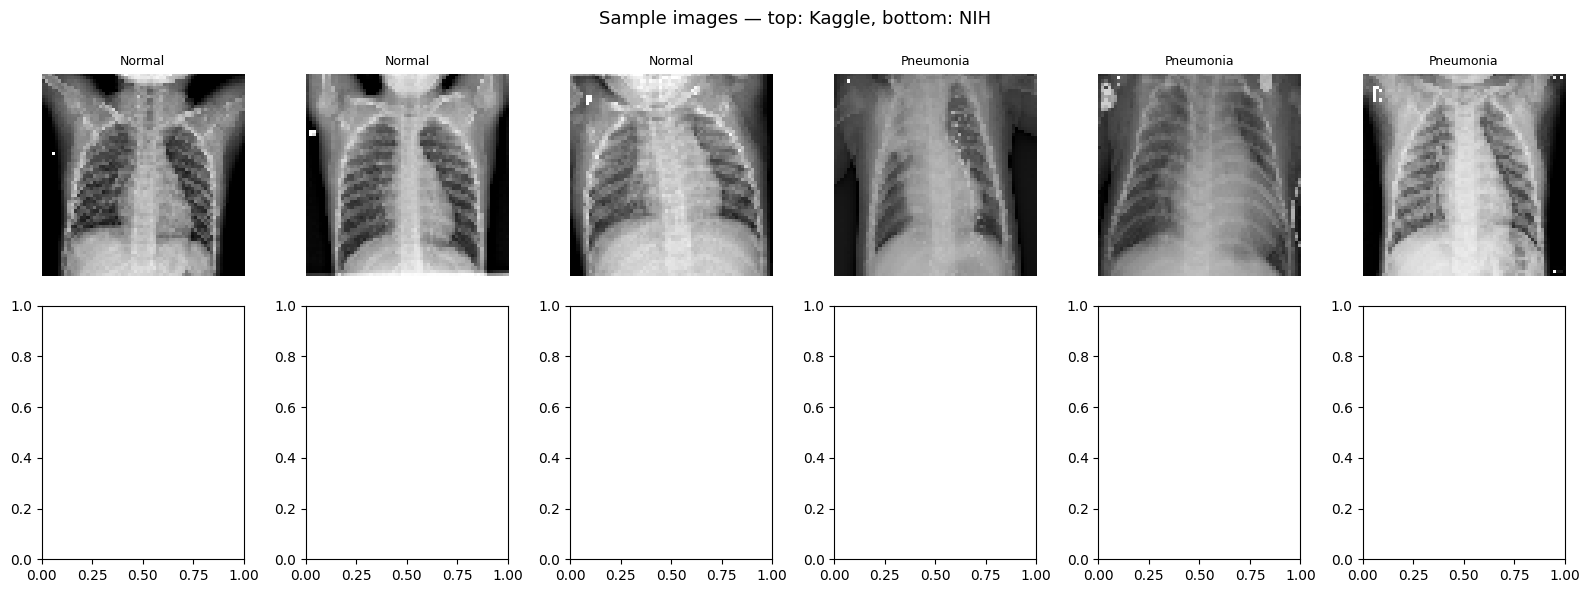

Figure saved as sample_images.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample images — top: Kaggle, bottom: NIH', fontsize=13)

# Top row: Kaggle (3 Normal, 3 Pneumonia)
kaggle_normal_idx = np.where(y_train == 0)[0][:3]
kaggle_pneum_idx  = np.where(y_train == 1)[0][:3]
for i, idx in enumerate(list(kaggle_normal_idx) + list(kaggle_pneum_idx)):
    axes[0, i].imshow(X_train[idx], cmap='gray')
    axes[0, i].set_title('Normal' if y_train[idx] == 0 else 'Pneumonia', fontsize=9)
    axes[0, i].axis('off')

# Bottom row: NIH (3 Normal, 3 Pneumonia)
nih_normal_idx = np.where(y_nih == 0)[0][:3]
nih_pneum_idx  = np.where(y_nih == 1)[0][:3]
for i, idx in enumerate(list(nih_normal_idx) + list(nih_pneum_idx)):
    axes[1, i].imshow(X_nih[idx], cmap='gray')
    axes[1, i].set_title('Normal' if y_nih[idx] == 0 else 'Pneumonia', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as sample_images.png')

## Step 8 — Saves preprocessed arrays for use in later notebooks

In [18]:
os.makedirs('preprocessed', exist_ok=True)

np.save('preprocessed/X_train.npy', X_train)
np.save('preprocessed/y_train.npy', y_train)
np.save('preprocessed/X_test.npy',  X_test)
np.save('preprocessed/y_test.npy',  y_test)
np.save('preprocessed/X_nih.npy',   X_nih)
np.save('preprocessed/y_nih.npy',   y_nih)

print('All arrays saved to /preprocessed/')
print()
print('Summary:')
print(f'  X_train : {X_train.shape}  — Kaggle training images')
print(f'  y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}   — Kaggle test images')
print(f'  y_test  : {y_test.shape}')
print(f'  X_nih   : {X_nih.shape}    — NIH generalization images')
print(f'  y_nih   : {y_nih.shape}')
print()
print('Notebook 1 complete. Open notebook 2 (K-Means segmentation) next.')

All arrays saved to /preprocessed/

Summary:
  X_train : (5216, 64, 64)  — Kaggle training images
  y_train : (5216,)
  X_test  : (624, 64, 64)   — Kaggle test images
  y_test  : (624,)
  X_nih   : (0,)    — NIH generalization images
  y_nih   : (0,)

Notebook 1 complete. Open notebook 2 (K-Means segmentation) next.
